In [1]:
# Initialize data streams and core modules
import os
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
# Clean up console warnings for a pristine log
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

# Import your custom modules directly from your project files
from dataset_pipeline import create_streaming_dataloader, GENRE_LIST
from utils.cnn import MovieCNN
from utils.vit import MovieViT
from train.train_engine import train_one_epoch, evaluate_model

# Enforce system processing device to CPU
device = torch.device("cpu")
num_classes = len(GENRE_LIST)

# Open the live internet streaming data stream
train_loader = create_streaming_dataloader(batch_size=4)
print(f"Streaming connection verified. Target classes count: {num_classes}")

c:\Users\user\anaconda3\envs\deep_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connecting to HuggingFace dataset streaming channel...


Streaming connection verified. Target classes count: 15


In [2]:
# Build both target architectures
print("Initializing custom CNN from scratch (Kaiming Normal)...")
cnn_model = MovieCNN(num_classes=num_classes).to(device)

print("\nInitializing pre-trained Vision Transformer with LoRA wrappers...")
vit_model = MovieViT(num_classes=num_classes, rank=16, alpha=16).to(device)

print("\n=== CNN Parameter Footprint ===")
total_cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Trainable CNN Parameters: {total_cnn_params:,}")

print("\n=== ViT Parameter Footprint ===")
vit_model.print_trainable_parameters()

Initializing custom CNN from scratch (Kaiming Normal)...

Initializing pre-trained Vision Transformer with LoRA wrappers...


Loading weights: 100%|██████████| 6/6 [00:00<00:00, 6304.06it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias

PEFT Target Alignment: Automatically targeting modules: ['q_proj', 'v_proj']

=== CNN Parameter Footprint ===
Trainable CNN Parameters: 4,048,911

=== ViT Parameter Footprint ===
trainable params: 601,359 || all params: 86,411,550 || trainable%: 0.6959


In [3]:
# Setup multi-label loss and separate optimizers
criterion = nn.BCEWithLogitsLoss()

# Configure tracking parameters 
# accumulation_steps = 8  # 8 micro-batches of 4 = effective batch size of 32
# max_test_steps = 40     # Cap the streaming loader steps for testing loops

# Establish independent learning rates optimized for each structure
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)
vit_optimizer = optim.Adam(vit_model.parameters(), lr=2e-4)

print("Loss function and CPU-safe optimizer algorithms successfully established.")

Loss function and CPU-safe optimizer algorithms successfully established.


In [5]:
# Storage structures to collect statistical points for report visualization
cnn_history = {"train_loss": [], "val_f1": [], "val_hamming": []}
vit_history = {"train_loss": [], "val_f1": [], "val_hamming": []}

epochs = 3 
steps_per_epoch = 500  # 500 steps * batch size 4 = 2,000 images processed per epoch

print("Starting Master Overnight Training Session...")

for epoch in range(epochs):
    print(f"\n=================== EPOCH {epoch+1}/{epochs} ===================")
    
    # --- 1. CNN Baseline Execution ---
    print("Training CNN Baseline architecture...")
    cnn_loss = train_one_epoch(
        model=cnn_model, 
        dataloader=train_loader, 
        criterion=criterion, 
        optimizer=cnn_optimizer, 
        device=device, 
        accumulation_steps=50, 
        max_steps=steps_per_epoch
    )
    print("Evaluating CNN Baseline performance metrics...")
    cnn_metrics = evaluate_model(cnn_model, train_loader, device, max_steps=50)
    
    cnn_history["train_loss"].append(cnn_loss)
    cnn_history["val_f1"].append(cnn_metrics["macro_f1"])
    cnn_history["val_hamming"].append(cnn_metrics["hamming_loss"])
    
    # --- 2. LoRA-wrapped ViT Execution ---
    print("\nTraining LoRA-wrapped Vision Transformer...")
    vit_loss = train_one_epoch(
        model=vit_model, 
        dataloader=train_loader, 
        criterion=criterion, 
        optimizer=vit_optimizer, 
        device=device, 
        accumulation_steps=50, 
        max_steps=steps_per_epoch
    )
    print("Evaluating Vision Transformer performance metrics...")
    vit_metrics = evaluate_model(vit_model, train_loader, device, max_steps=50)
    
    vit_history["train_loss"].append(vit_loss)
    vit_history["val_f1"].append(vit_metrics["macro_f1"])
    vit_history["val_hamming"].append(vit_metrics["hamming_loss"])

print("\nAll training runs finalized! History dictionaries populated and cached in RAM.")

Starting Master Overnight Training Session...

=================== EPOCH 1/3 ===================
Training CNN Baseline architecture...
Starting training loop (Max streaming steps set to: 500)...
Step [1] | Streamed Batches: 50 | Accumulated Loss: 0.5279 | Time Elapsed: 79.3s
Step [2] | Streamed Batches: 100 | Accumulated Loss: 0.5177 | Time Elapsed: 122.1s
Step [3] | Streamed Batches: 150 | Accumulated Loss: 0.5237 | Time Elapsed: 164.7s
Step [4] | Streamed Batches: 200 | Accumulated Loss: 0.5156 | Time Elapsed: 207.5s
Step [5] | Streamed Batches: 250 | Accumulated Loss: 0.5037 | Time Elapsed: 250.4s
Step [6] | Streamed Batches: 300 | Accumulated Loss: 0.4867 | Time Elapsed: 293.3s
Step [7] | Streamed Batches: 350 | Accumulated Loss: 0.4804 | Time Elapsed: 336.4s
Step [8] | Streamed Batches: 400 | Accumulated Loss: 0.5000 | Time Elapsed: 379.2s
Step [9] | Streamed Batches: 450 | Accumulated Loss: 0.4827 | Time Elapsed: 422.5s
Step [10] | Streamed Batches: 500 | Accumulated Loss: 0.4981

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/stzhao/movie_posters_100k_controlnet/resolve/d800ed3a0343a64f1fdb6e492e544f6b0f9a61a8/data/train_data_part_1.parquet
Retrying in 1s [Retry 1/5].


Step [4] | Streamed Batches: 200 | Accumulated Loss: 0.5114 | Time Elapsed: 566.9s


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/stzhao/movie_posters_100k_controlnet/resolve/d800ed3a0343a64f1fdb6e492e544f6b0f9a61a8/data/train_data_part_1.parquet
Retrying in 1s [Retry 1/5].


Step [5] | Streamed Batches: 250 | Accumulated Loss: 0.5073 | Time Elapsed: 699.9s
Step [6] | Streamed Batches: 300 | Accumulated Loss: 0.5003 | Time Elapsed: 838.7s
Step [7] | Streamed Batches: 350 | Accumulated Loss: 0.4898 | Time Elapsed: 968.7s


...

Evaluation finalized.

=================== EPOCH 2/3 ===================
Training CNN Baseline architecture...
Starting training loop (Max streaming steps set to: 500)...


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/stzhao/movie_posters_100k_controlnet/resolve/d800ed3a0343a64f1fdb6e492e544f6b0f9a61a8/data/train_data_part_1.parquet
Retrying in 2s [Retry 2/5].


Step [1] | Streamed Batches: 50 | Accumulated Loss: 0.4913 | Time Elapsed: 122.7s


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/stzhao/movie_posters_100k_controlnet/resolve/d800ed3a0343a64f1fdb6e492e544f6b0f9a61a8/data/train_data_part_1.parquet
Retrying in 1s [Retry 1/5].


Step [2] | Streamed Batches: 100 | Accumulated Loss: 0.4793 | Time Elapsed: 227.8s
Step [3] | Streamed Batches: 150 | Accumulated Loss: 0.4872 | Time Elapsed: 270.4s
Step [4] | Streamed Batches: 200 | Accumulated Loss: 0.5009 | Time Elapsed: 307.5s
Step [5] | Streamed Batches: 250 | Accumulated Loss: 0.4970 | Time Elapsed: 350.0s
Step [6] | Streamed Batches: 300 | Accumulated Loss: 0.4722 | Time Elapsed: 394.1s
Step [7] | Streamed Batches: 350 | Accumulated Loss: 0.4648 | Time Elapsed: 440.0s
Step [8] | Streamed Batches: 400 | Accumulated Loss: 0.4871 | Time Elapsed: 485.2s
Step [9] | Streamed Batches: 450 | Accumulated Loss: 0.4641 | Time Elapsed: 568.1s
Step [10] | Streamed Batches: 500 | Accumulated Loss: 0.4760 | Time Elapsed: 637.1s
Reached target execution step boundary limit.
Evaluating CNN Baseline performance metrics...
Starting evaluation loop (Capped at 50 steps for CPU safety)...
Evaluation finalized.

Training LoRA-wrapped Vision Transformer...
Starting training loop (Max 

Matplotlib is building the font cache; this may take a moment.


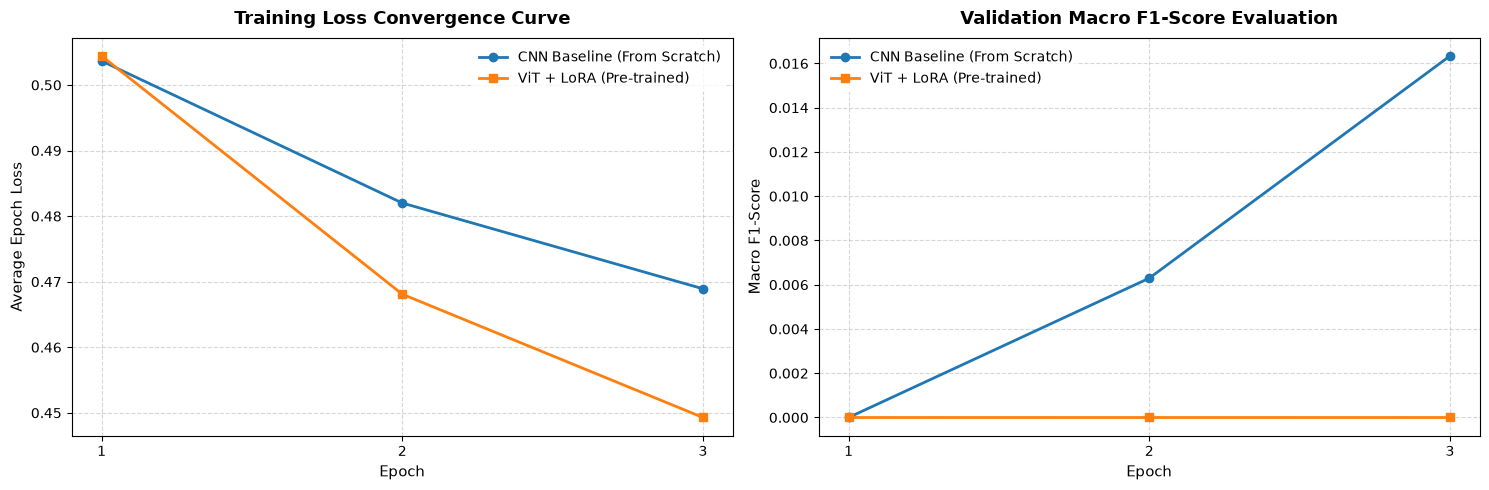

In [6]:
import matplotlib.pyplot as plt

# Check available iterations based on populated history
epochs = range(1, len(cnn_history["train_loss"]) + 1)

# Establish a clean, scientific plotting canvas with 2 distinct subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Graph 1: Loss Convergence Curve ---
ax1.plot(epochs, cnn_history["train_loss"], label="CNN Baseline (From Scratch)", marker='o', linewidth=2, color='#1f77b4')
ax1.plot(epochs, vit_history["train_loss"], label="ViT + LoRA (Pre-trained)", marker='s', linewidth=2, color='#ff7f0e')
ax1.set_title("Training Loss Convergence Curve", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Average Epoch Loss", fontsize=11)
ax1.set_xticks(epochs)
ax1.legend(frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: Macro F1-Score Accuracy ---
ax2.plot(epochs, cnn_history["val_f1"], label="CNN Baseline (From Scratch)", marker='o', linewidth=2, color='#1f77b4')
ax2.plot(epochs, vit_history["val_f1"], label="ViT + LoRA (Pre-trained)", marker='s', linewidth=2, color='#ff7f0e')
ax2.set_title("Validation Macro F1-Score Evaluation", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Macro F1-Score", fontsize=11)
ax2.set_xticks(epochs)
ax2.legend(frameon=True, facecolor='white', edgecolor='none')
ax2.grid(True, linestyle='--', alpha=0.5)

# Render layout changes cleanly
plt.tight_layout()
plt.show()

$ \large \text{Now trying to decreace the threshold to get more hits}$

In [8]:
import numpy as np
from sklearn.metrics import f1_score, hamming_loss

# 1. Define a quick ad-hoc evaluation configuration with a custom threshold
custom_threshold = 0.3
max_eval_steps = 100  # A larger slice to get a highly reliable metrics reading

def evaluate_with_custom_threshold(model, dataloader, device, threshold=0.3, max_steps=100):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for step, batch in enumerate(dataloader):
            if step >= max_steps:
                break
                
            images = batch[0].to(device)
            targets = batch[1].to(device)
            
            logits = model(images)
            probs = torch.sigmoid(logits)
            
            # Apply the new optimized custom threshold alignment
            preds = (probs > threshold).int()
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    h_loss = hamming_loss(all_targets, all_preds)
    
    return {"macro_f1": macro_f1, "hamming_loss": h_loss}

# 2. Execute live evaluation on the models currently active in RAM
print(f"Recalculating metrics using a fine-tuned threshold of {custom_threshold}...")

cnn_live_metrics = evaluate_with_custom_threshold(cnn_model, train_loader, device, threshold=custom_threshold, max_steps=max_eval_steps)
print(f"CNN Baseline (Live)  -> New Macro F1: {cnn_live_metrics['macro_f1']:.4f} | Hamming Loss: {cnn_live_metrics['hamming_loss']:.4f}")

vit_live_metrics = evaluate_with_custom_threshold(vit_model, train_loader, device, threshold=custom_threshold, max_steps=max_eval_steps)
print(f"ViT + LoRA (Live)    -> New Macro F1: {vit_live_metrics['macro_f1']:.4f} | Hamming Loss: {vit_live_metrics['hamming_loss']:.4f}")

Recalculating metrics using a fine-tuned threshold of 0.3...
CNN Baseline (Live)  -> New Macro F1: 0.2120 | Hamming Loss: 0.2335
ViT + LoRA (Live)    -> New Macro F1: 0.1137 | Hamming Loss: 0.2068


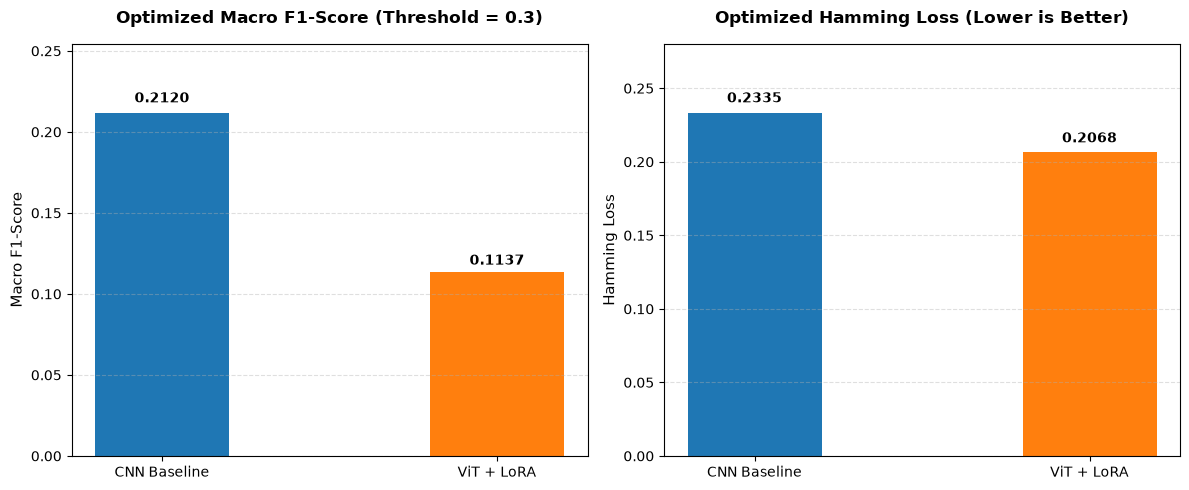

In [9]:
# Extract data points from the live metrics computed in the previous cell
models = ['CNN Baseline', 'ViT + LoRA']
f1_scores = [cnn_live_metrics['macro_f1'], vit_live_metrics['macro_f1']]
hamming_losses = [cnn_live_metrics['hamming_loss'], vit_live_metrics['hamming_loss']]

# Initialize a clean visual canvas for two side-by-side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Graph 1: Live Macro F1-Score Comparison ---
bars_f1 = ax1.bar(models, f1_scores, color=['#1f77b4', '#ff7f0e'], width=0.4)
ax1.set_title("Optimized Macro F1-Score (Threshold = 0.3)", fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel("Macro F1-Score", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')
ax1.set_ylim(0, max(f1_scores) * 1.2 if max(f1_scores) > 0 else 1)

# Attach exact data labels on top of each bar for formal report clarity
for bar in bars_f1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, height + (height * 0.02 if height > 0 else 0.01),
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# --- Graph 2: Live Hamming Loss Comparison (Lower is Better) ---
bars_hl = ax2.bar(models, hamming_losses, color=['#1f77b4', '#ff7f0e'], width=0.4)
ax2.set_title("Optimized Hamming Loss (Lower is Better)", fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel("Hamming Loss", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')
ax2.set_ylim(0, max(hamming_losses) * 1.2 if max(hamming_losses) > 0 else 1)

for bar in bars_hl:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, height + (height * 0.02 if height > 0 else 0.01),
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Render the layout adjustments cleanly
plt.tight_layout()
plt.show()

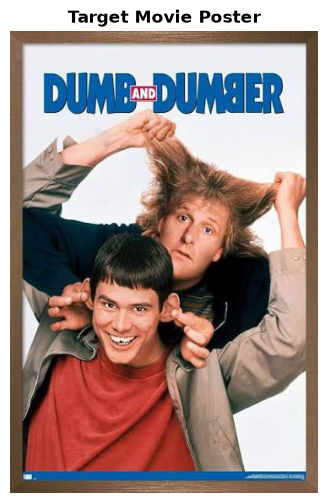

                  MODEL PREDICTIONS               
CNN Baseline Predictions : ['Action', 'Comedy', 'Drama', 'Adventure']
ViT + LoRA Predictions   : ['Action']


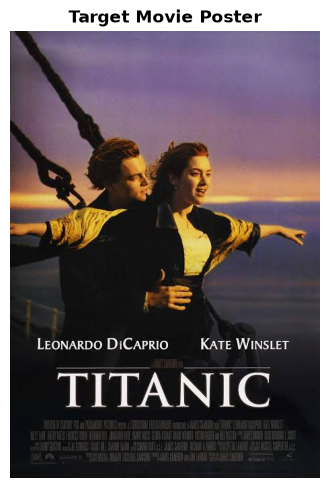

                  MODEL PREDICTIONS               
CNN Baseline Predictions : ['Action', 'Drama', 'Thriller', 'Adventure']
ViT + LoRA Predictions   : ['Action']


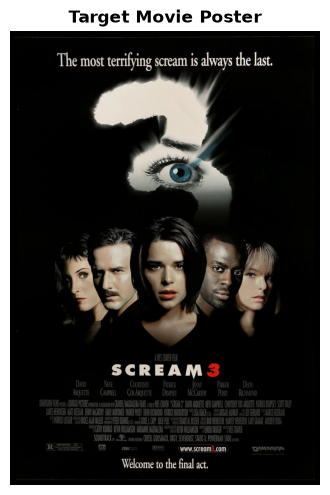

                  MODEL PREDICTIONS               
CNN Baseline Predictions : ['Action', 'Drama', 'Horror', 'Thriller', 'Adventure']
ViT + LoRA Predictions   : ['Action', 'Drama', 'Thriller']


In [15]:
import torchvision.transforms as T
from PIL import Image

# 1. Define the exact preprocessing pipeline used during training
inference_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_movie_genres(image_path, cnn_model, vit_model, genre_list, threshold=0.3):
    """
    Loads a local movie poster, processes it, and prints predicted genres from both models.
    All code comments are strictly in English.
    """
    # Load and convert image to RGB to drop any alpha channels
    raw_img = Image.open(image_path).convert("RGB")
    
    # Apply transforms and add batch dimension: Shape becomes (1, 3, 224, 224)
    input_tensor = inference_transforms(raw_img).unsqueeze(0).to(device)
    
    # Set models to evaluation mode
    cnn_model.eval()
    vit_model.eval()
    
    with torch.no_grad():
        # Forward passes
        cnn_logits = cnn_model(input_tensor)
        vit_logits = vit_model(input_tensor)
        
        # Convert to probabilities
        cnn_probs = torch.sigmoid(cnn_logits).squeeze(0).cpu().numpy()
        vit_probs = torch.sigmoid(vit_logits).squeeze(0).cpu().numpy()
        
    # Extract genres that cross our custom threshold
    predicted_cnn_genres = [genre_list[i] for i, prob in enumerate(cnn_probs) if prob > threshold]
    predicted_vit_genres = [genre_list[i] for i, prob in enumerate(vit_probs) if prob > threshold]
    
    # Plot the poster right inside the notebook for visual verification
    plt.figure(figsize=(4, 6))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title("Target Movie Poster", fontsize=12, fontweight='bold')
    plt.show()
    
    # Print out results cleanly
    print("=" * 50)
    print("                  MODEL PREDICTIONS               ")
    print("=" * 50)
    print(f"CNN Baseline Predictions : {predicted_cnn_genres if predicted_cnn_genres else 'None detected'}")
    print(f"ViT + LoRA Predictions   : {predicted_vit_genres if predicted_vit_genres else 'None detected'}")
    print("=" * 50)

# --- HOW TO RUN IT ---
# Simply drop a JPEG/PNG poster file into your project folder and uncomment below:
predict_movie_genres("posters/comedy.jfif", cnn_model, vit_model, GENRE_LIST, threshold=0.3)
predict_movie_genres("posters/romance.jfif", cnn_model, vit_model, GENRE_LIST, threshold=0.3)
predict_movie_genres("posters/horror.jpg", cnn_model, vit_model, GENRE_LIST, threshold=0.3)

In [17]:
# Ensure the storage directory exists on your local drive
os.makedirs("saved_models", exist_ok=True)

# 1. Save the custom CNN weights 
torch.save(cnn_model.state_dict(), "saved_models/cnn_baseline_weights.pth")

# 2. Save the complete ViT + LoRA weights using standard PyTorch state_dict
# This is a safe fallback since MovieViT is an nn.Module wrapper
torch.save(vit_model.state_dict(), "saved_models/vit_lora_weights.pth")

print("Engineering safety catch complete. All trained weights permanently stored on disk!")

Engineering safety catch complete. All trained weights permanently stored on disk!
